In [1]:
import eeg_lib as eeg
import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import load_dataset
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {device}")

Device: mps


In [2]:
ds = load_dataset("DavidVivancos/MindBigData2022_MNIST_EP")

X_train, y_train = eeg.df_to_raw(ds["train"].to_pandas())
X_test, y_test = eeg.df_to_raw(ds["test"].to_pandas())

print(f"Train+val: {X_train.shape}, Test: {X_test.shape}")
print(f"Klasy: {np.unique(y_train)}, rozkład: {np.bincount(y_train)}")

Train+val: (51895, 14, 256), Test: (12980, 14, 256)
Klasy: [0 1 2 3 4 5 6 7 8 9], rozkład: [5212 5080 5196 5294 5079 5256 5218 5069 5241 5250]


In [3]:
X_train_norm = eeg.zscore_per_epoch(X_train)
X_test_norm = eeg.zscore_per_epoch(X_test)

X_train_norm, X_val_norm, y_train, y_val = train_test_split(X_train_norm, y_train, test_size=0.2, stratify=y_train, random_state=SEED)

print(f"Train: {X_train_norm.shape}, Val: {X_val_norm.shape}, Test: {X_test_norm.shape}")

Train: (41516, 14, 256), Val: (10379, 14, 256), Test: (12980, 14, 256)


In [4]:
WIN, STEP = 128, 16            # okno 1 s, ~9 okien na epokę

X_tr_c, y_tr_c = eeg.crop(X_train_norm, y_train, WIN, STEP)

In [5]:

train_loader = eeg.make_loader(X_tr_c, y_tr_c, batch=128, shuffle=True)
val_loader = eeg.make_loader(X_val_norm, y_val, batch=256)
test_loader = eeg.make_loader(X_test_norm, y_test, batch=256)

In [ ]:
import time
from pathlib import Path

print("EEGNet (Lawhern)")
eegnet = eeg.EEGNet(n_ch=14, n_time=WIN, n_classes=10, F1=32, D=2, F2=64, kern=32, p=0.3).to(device)
print(f"Parametry: {sum(p.numel() for p in eegnet.parameters()):,}")
eegnet, hist_egn = eeg.train_model_grouped(eegnet, train_loader, X_val_norm, y_val, device, 128, WIN, STEP,
                                epochs=200, lr=5e-4, patience=40, use_augment=False, log_every=5)

timestamp = int(time.time())
folder = Path("..") / Path("models")
torch.save(eegnet.state_dict(), folder / f"eegnet_raw_windowing_{timestamp}.pth")
print(f"Model saved to {folder / f'eegnet_raw_windowing_{timestamp}.pth'}")

EEGNet (Lawhern)
Parametry: 9,930
  ep 01  train_acc=0.123  val_acc=0.157  val_f1=0.122
  ep 05  train_acc=0.144  val_acc=0.172  val_f1=0.140
  ep 10  train_acc=0.150  val_acc=0.172  val_f1=0.150
  ep 15  train_acc=0.153  val_acc=0.172  val_f1=0.152
  ep 20  train_acc=0.155  val_acc=0.179  val_f1=0.150
  ep 25  train_acc=0.156  val_acc=0.174  val_f1=0.149
  ep 30  train_acc=0.157  val_acc=0.171  val_f1=0.145
  ep 35  train_acc=0.157  val_acc=0.176  val_f1=0.150
  ep 40  train_acc=0.158  val_acc=0.175  val_f1=0.147
  ep 45  train_acc=0.160  val_acc=0.172  val_f1=0.144
  ep 50  train_acc=0.160  val_acc=0.171  val_f1=0.147
  ep 55  train_acc=0.160  val_acc=0.175  val_f1=0.155
  ep 60  train_acc=0.161  val_acc=0.172  val_f1=0.149
  ep 65  train_acc=0.161  val_acc=0.170  val_f1=0.152
  early stop @ epoch 66 (best val_f1=0.161)


In [13]:

timestamp = int(time.time())
folder = Path("..") / Path("models")
torch.save(eegnet.state_dict(), folder / f"eegnet_raw_windowing_{timestamp}.pth")
print(f"Model saved to {folder / f'eegnet_raw_windowing_{timestamp}.pth'}")

Model saved to ../models/eegnet_raw_windowing_1780604411.pth


EEGNet (raw)  acc=0.1732  f1=0.1583
              precision    recall  f1-score   support

           0      0.164     0.401     0.233      1304
           1      0.173     0.153     0.163      1271
           2      0.174     0.063     0.093      1299
           3      0.147     0.109     0.125      1324
           4      0.166     0.116     0.136      1270
           5      0.186     0.300     0.230      1315
           6      0.160     0.130     0.143      1305
           7      0.247     0.316     0.277      1268
           8      0.135     0.088     0.107      1311
           9      0.115     0.058     0.077      1313

    accuracy                          0.173     12980
   macro avg      0.167     0.173     0.158     12980
weighted avg      0.166     0.173     0.158     12980



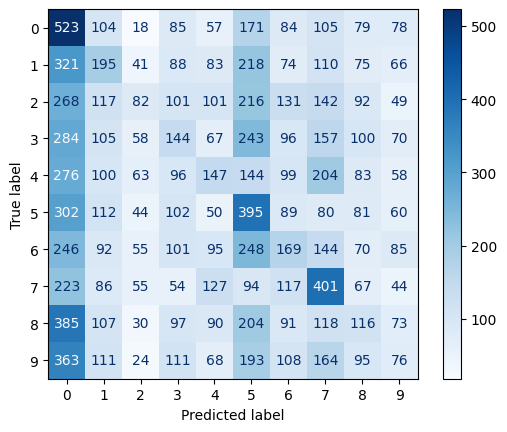

In [14]:
pred, acc, f1 = eeg.eval_grouped(eegnet, X_test_norm, y_test, device, 128, WIN, STEP)
print(f"EEGNet (raw)  acc={acc:.4f}  f1={f1:.4f}")
print(classification_report(y_test, pred, digits=3))
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=list(range(10))).plot(cmap="Blues")
plt.savefig(folder / f"eegnet_raw_windowing_{timestamp}_confusion_matrix.png", bbox_inches="tight", dpi=300)

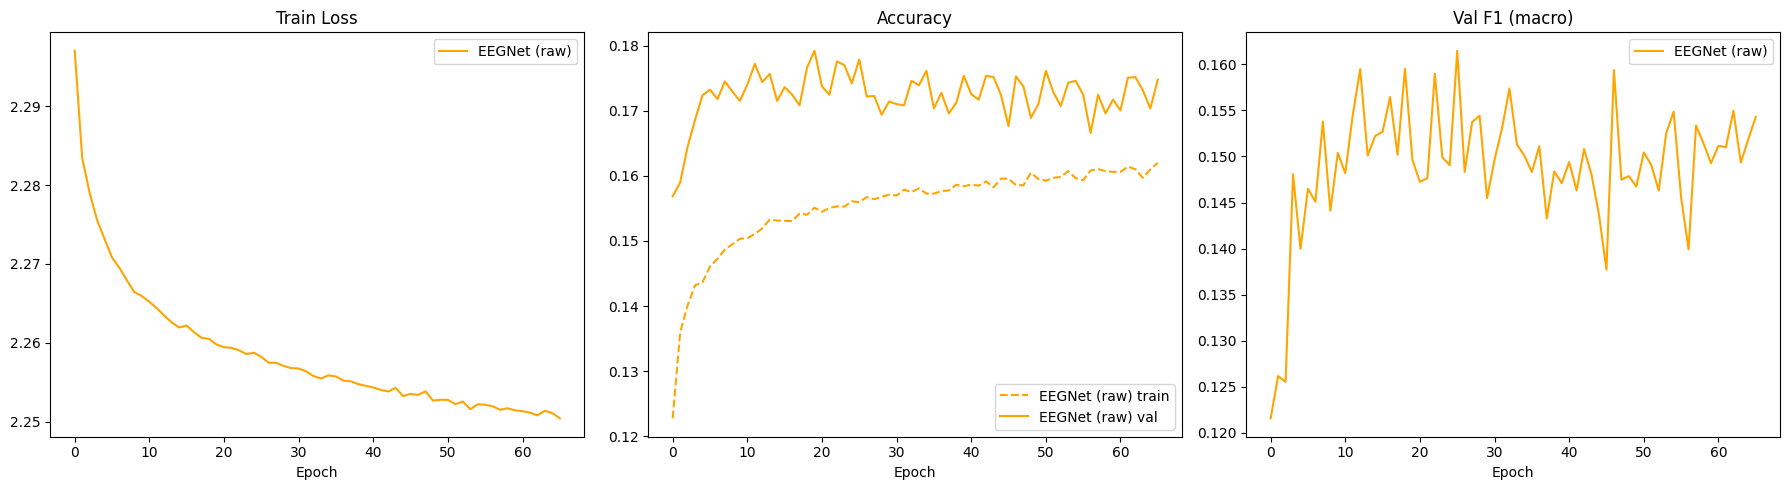

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

name = "EEGNet (raw)"
color = "orange"
axes[0].plot(hist_egn["train_loss"], label=name, color=color)
axes[1].plot(hist_egn["train_acc"], label=f"{name} train", color=color, linestyle="--")
axes[1].plot(hist_egn["val_acc"], label=f"{name} val", color=color)
axes[2].plot(hist_egn["val_f1"], label=name, color=color)

axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[2].set_title("Val F1 (macro)")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.savefig(folder / f"eegnet_raw_windowing_{timestamp}_training_curves.png", bbox_inches="tight", dpi=300)
plt.show()